# B-V and V-K Temperature Analysis

This notebook analyzes the newly calculated temperature estimates from B-V and V-K color indices:
- **Te_bv**: Effective temperature from B-V color using piecewise polynomial relations
- **Te_vk**: Effective temperature from V-K color using piecewise polynomial relations

We compare these temperatures with:
- Gaia T_eff (teff_gspphot)
- Pan-STARRS color-derived temperatures (Te_gr, Te_ri, Te_iz, Te_avg)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths
data_dir = Path('../data/processed')

# Load the Gaia catalog with proper motion
print("Loading Gaia catalog with proper motion...")
gaia_pm = pd.read_parquet(data_dir / 'eb_catalog_with_pm.parquet')
print(f"Gaia PM catalog shape: {gaia_pm.shape}")

# Load the Pan-STARRS photometry with temperatures (including new Te_bv and Te_vk)
print("Loading Pan-STARRS photometry with all temperatures...")
panstarrs_temp = pd.read_parquet(data_dir / 'gaia_eb_panstarrs_phot_with_temperatures.parquet')
print(f"Pan-STARRS temperature catalog shape: {panstarrs_temp.shape}")

# Join the tables on original_ext_source_id
print("Joining tables on original_ext_source_id...")
merged = gaia_pm.merge(panstarrs_temp, on='original_ext_source_id', how='inner')
print(f"Merged catalog shape: {merged.shape}")

print(f"\nMerged catalog columns: {len(merged.columns)}")
print(f"\nAvailable temperature measurements:")
print(f"  Gaia teff_gspphot > 0: {(merged['teff_gspphot'] > 0).sum():,} objects")
print(f"  Te_avg != -999.0: {(merged['Te_avg'] != -999.0).sum():,} objects")
print(f"  Te_bv (not null): {merged['Te_bv'].notna().sum():,} objects")
print(f"  Te_vk (not null): {merged['Te_vk'].notna().sum():,} objects")

merged.head()


Loading Gaia catalog with proper motion...
Gaia PM catalog shape: (1230649, 15)
Loading Pan-STARRS photometry with all temperatures...
Pan-STARRS temperature catalog shape: (1172535, 29)
Joining tables on original_ext_source_id...
Merged catalog shape: (1172580, 43)

Merged catalog columns: 43

Available temperature measurements:
  Gaia teff_gspphot > 0: 720,005 objects
  Te_avg != -999.0: 1,172,047 objects
  Te_bv (not null): 1,143,551 objects
  Te_vk (not null): 1,129,605 objects


,source_id,clean_panstarrs1_oid,original_ext_source_id,l,b,pmra,pmdec,pseudocolour,phot_g_mean_mag,phot_bp_mean_mag,...,Te_iz,Te_avg,temp_measurement_count,B_mag,V_mag,B_V_color,R_I_color,V_K_color,Te_bv,Te_vk
0,46626164993792,967166606,108690456271144410,176.988972,-48.049800,2.203996,-6.068640,NaN,19.931410,20.556221,...,5598.938292,5529.746199,3,20.745109,20.128758,0.616351,0.382500,1.601209,5929.171379,5684.134810
1,104487964717440,972259318,108950446169939982,175.688254,-48.616774,-1.782626,-18.938406,NaN,17.909193,19.156775,...,3786.527774,3547.725169,3,20.075677,18.747249,1.328427,1.204235,3.880688,4086.685886,3622.699565
2,138577120584320,978183638,109270450082003814,175.823945,-48.154829,0.259084,-0.413995,NaN,15.532284,15.748469,...,4685.570589,5500.558507,3,16.230204,15.680795,0.549409,0.286599,1.365823,6165.716563,6048.632316
3,160219460292352,973703324,109030455555466575,176.608400,-47.903013,2.130611,-6.538687,NaN,17.597319,18.101242,...,5154.649759,5011.609940,3,18.537989,17.812619,0.725370,0.544001,1.990567,5579.622054,5186.678760
4,203551385701760,982701946,109510460340003115,176.680029,-47.283171,-21.000783,-43.917424,NaN,13.413368,14.149869,...,3721.113012,4600.414120,3,14.940516,13.979548,0.960968,0.372200,2.242953,4959.016580,4919.104854


Objects with both Gaia T_eff and Te_bv: 712,811


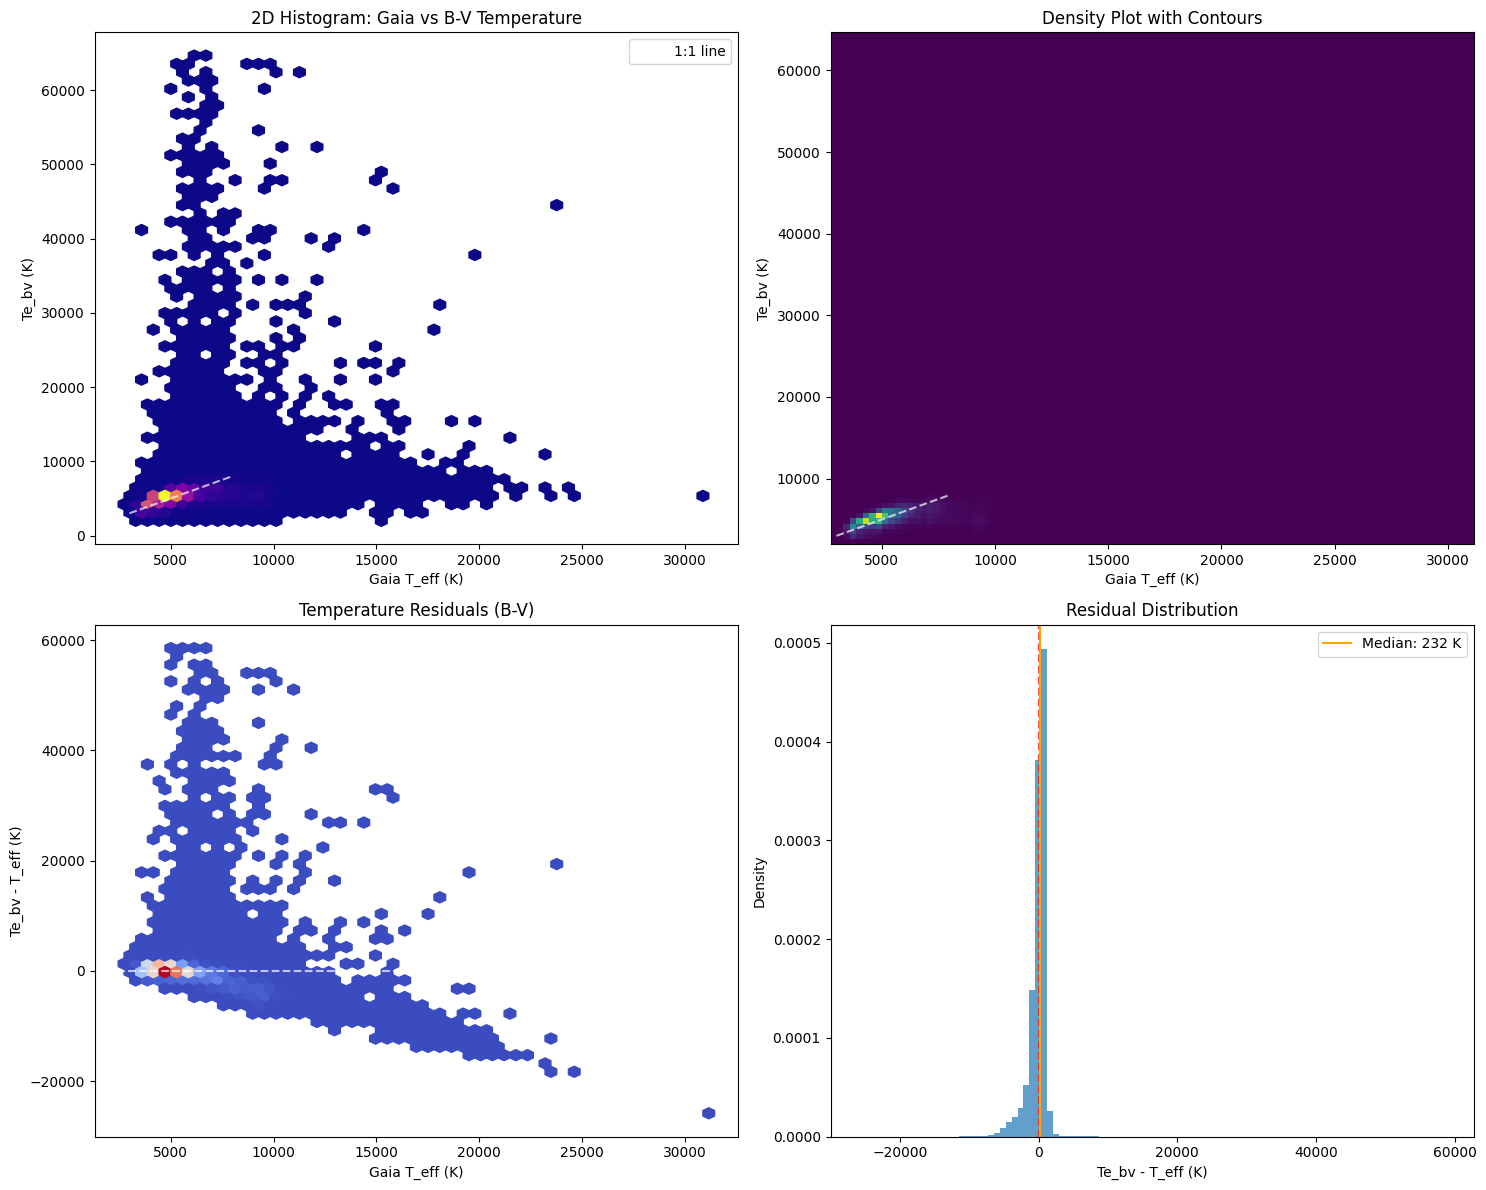


Temperature comparison statistics (Gaia vs Te_bv):
Gaia T_eff range: 2737 - 31144 K
Te_bv range: 1985 - 64665 K
Median residual (Te_bv - T_eff): 232 K
MAD residual: 473 K
RMS residual: 1449 K


In [2]:
# Plot Gaia T_eff vs Te_bv (B-V derived temperature)
# Filter for valid temperature measurements
valid_temp = (merged['teff_gspphot'] > 0) & (merged['Te_bv'].notna())
temp_data = merged[valid_temp]

print(f"Objects with both Gaia T_eff and Te_bv: {len(temp_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D histogram (hexbin plot)
axes[0,0].hexbin(temp_data['teff_gspphot'], temp_data['Te_bv'],
                gridsize=50, cmap='plasma', mincnt=1)
axes[0,0].set_xlabel('Gaia T_eff (K)')
axes[0,0].set_ylabel('Te_bv (K)')
axes[0,0].set_title('2D Histogram: Gaia vs B-V Temperature')
axes[0,0].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7, label='1:1 line')
axes[0,0].legend()

# Density plot with contours
axes[0,1].hist2d(temp_data['teff_gspphot'], temp_data['Te_bv'],
                bins=100, cmap='viridis', density=True)
axes[0,1].set_xlabel('Gaia T_eff (K)')
axes[0,1].set_ylabel('Te_bv (K)')
axes[0,1].set_title('Density Plot with Contours')
axes[0,1].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7)

# Residuals vs Gaia T_eff
residuals = temp_data['Te_bv'] - temp_data['teff_gspphot']
axes[1,0].hexbin(temp_data['teff_gspphot'], residuals,
                gridsize=50, cmap='coolwarm', mincnt=1)
axes[1,0].set_xlabel('Gaia T_eff (K)')
axes[1,0].set_ylabel('Te_bv - T_eff (K)')
axes[1,0].set_title('Temperature Residuals (B-V)')
axes[1,0].axhline(y=0, color='white', linestyle='--', alpha=0.7)

# Distribution of residuals
axes[1,1].hist(residuals, bins=100, alpha=0.7, density=True)
axes[1,1].set_xlabel('Te_bv - T_eff (K)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=np.median(residuals), color='orange', linestyle='-',
                    label=f'Median: {np.median(residuals):.0f} K')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTemperature comparison statistics (Gaia vs Te_bv):")
print(f"Gaia T_eff range: {temp_data['teff_gspphot'].min():.0f} - {temp_data['teff_gspphot'].max():.0f} K")
print(f"Te_bv range: {temp_data['Te_bv'].min():.0f} - {temp_data['Te_bv'].max():.0f} K")
print(f"Median residual (Te_bv - T_eff): {np.median(residuals):.0f} K")
print(f"MAD residual: {np.median(np.abs(residuals - np.median(residuals))):.0f} K")
print(f"RMS residual: {np.sqrt(np.mean(residuals**2)):.0f} K")


Objects with both Gaia T_eff and Te_vk: 707,136


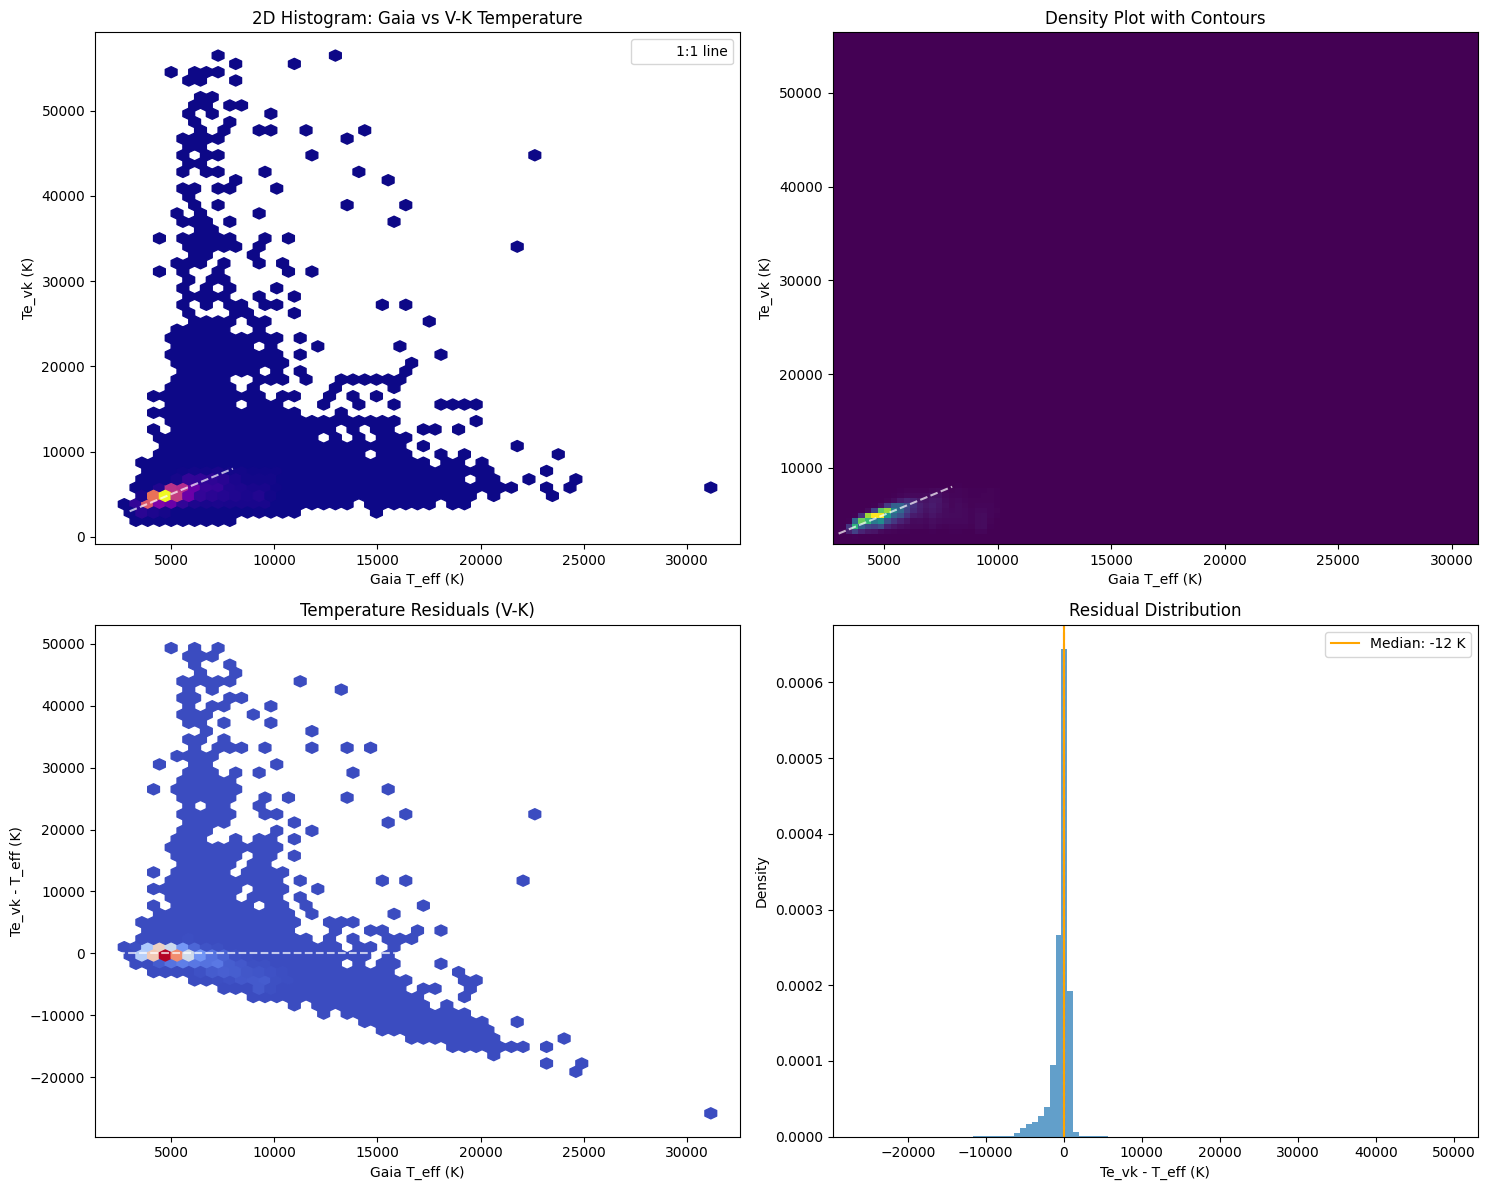


Temperature comparison statistics (Gaia vs Te_vk):
Gaia T_eff range: 2737 - 31144 K
Te_vk range: 1881 - 56458 K
Median residual (Te_vk - T_eff): -12 K
MAD residual: 422 K
RMS residual: 1393 K


In [3]:
# Plot Gaia T_eff vs Te_vk (V-K derived temperature)
# Filter for valid temperature measurements
valid_temp = (merged['teff_gspphot'] > 0) & (merged['Te_vk'].notna())
temp_data = merged[valid_temp]

print(f"Objects with both Gaia T_eff and Te_vk: {len(temp_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D histogram (hexbin plot)
axes[0,0].hexbin(temp_data['teff_gspphot'], temp_data['Te_vk'],
                gridsize=50, cmap='plasma', mincnt=1)
axes[0,0].set_xlabel('Gaia T_eff (K)')
axes[0,0].set_ylabel('Te_vk (K)')
axes[0,0].set_title('2D Histogram: Gaia vs V-K Temperature')
axes[0,0].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7, label='1:1 line')
axes[0,0].legend()

# Density plot with contours
axes[0,1].hist2d(temp_data['teff_gspphot'], temp_data['Te_vk'],
                bins=100, cmap='viridis', density=True)
axes[0,1].set_xlabel('Gaia T_eff (K)')
axes[0,1].set_ylabel('Te_vk (K)')
axes[0,1].set_title('Density Plot with Contours')
axes[0,1].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7)

# Residuals vs Gaia T_eff
residuals = temp_data['Te_vk'] - temp_data['teff_gspphot']
axes[1,0].hexbin(temp_data['teff_gspphot'], residuals,
                gridsize=50, cmap='coolwarm', mincnt=1)
axes[1,0].set_xlabel('Gaia T_eff (K)')
axes[1,0].set_ylabel('Te_vk - T_eff (K)')
axes[1,0].set_title('Temperature Residuals (V-K)')
axes[1,0].axhline(y=0, color='white', linestyle='--', alpha=0.7)

# Distribution of residuals
axes[1,1].hist(residuals, bins=100, alpha=0.7, density=True)
axes[1,1].set_xlabel('Te_vk - T_eff (K)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=np.median(residuals), color='orange', linestyle='-',
                    label=f'Median: {np.median(residuals):.0f} K')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTemperature comparison statistics (Gaia vs Te_vk):")
print(f"Gaia T_eff range: {temp_data['teff_gspphot'].min():.0f} - {temp_data['teff_gspphot'].max():.0f} K")
print(f"Te_vk range: {temp_data['Te_vk'].min():.0f} - {temp_data['Te_vk'].max():.0f} K")
print(f"Median residual (Te_vk - T_eff): {np.median(residuals):.0f} K")
print(f"MAD residual: {np.median(np.abs(residuals - np.median(residuals))):.0f} K")
print(f"RMS residual: {np.sqrt(np.mean(residuals**2)):.0f} K")
